<a href="https://colab.research.google.com/github/jcorrigan13/NLP_DeepLearningAssingmentforITNPAI/blob/main/ITNPAI1_Assingment_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install libraries

!pip install transformers datasets evaluate scikit-learn matplotlib pandas
!pip install kaggle
!pip install kagglehub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [ ]:
# Import packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [ ]:
# Kaggle setup
from google.colab import files
import os
import shutil

uploaded = files.upload()   # upload kaggle.json

os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Download dataset
!kaggle datasets download -d andrewmvd/trip-advisor-hotel-reviews

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/trip-advisor-hotel-reviews
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
  0% 0.00/5.14M [00:00<?, ?B/s]
100% 5.14M/5.14M [00:00<00:00, 832MB/s]


In [ ]:
# Download TripAdvisor data now
!kaggle datasets download -d andrewmvd/trip-advisor-hotel-reviews

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/trip-advisor-hotel-reviews
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
trip-advisor-hotel-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
#Downloading IMDB dataset

from datasets import load_dataset

imdb = load_dataset("imdb")
imdb_train = pd.DataFrame(imdb["train"])
imdb_test = pd.DataFrame(imdb["test"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Step 2:

Exploratory Data Analysis of the two datasets.

This is so we can understand what we are working with.

In [ ]:
#Intial investigation of Trip Advisor dataset:

# Checking collumns, labels

# Unzip the TripAdvisor dataset
!unzip -o /content/trip-advisor-hotel-reviews.zip

# Load the data into a pandas DataFrame
trip_df = pd.read_csv('tripadvisor_hotel_reviews.csv')


print(trip_df.columns)
print(trip_df.shape)
print(trip_df["Rating"].value_counts().sort_index())
trip_df.head()

Archive:  /content/trip-advisor-hotel-reviews.zip
  inflating: tripadvisor_hotel_reviews.csv  
Index(['Review', 'Rating'], dtype='object')
(20491, 2)
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


Index(['text', 'label'], dtype='object')
(25000, 2)
                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0


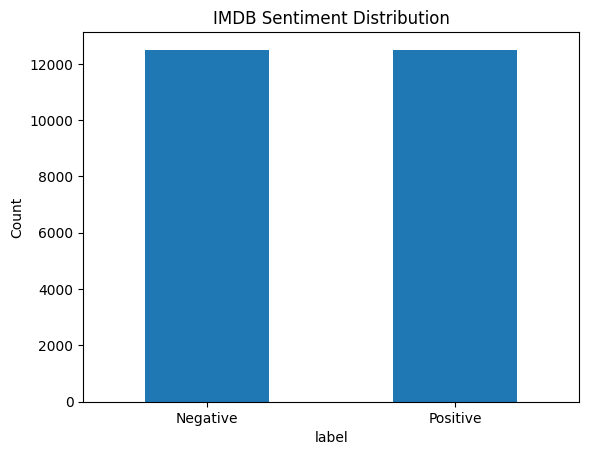

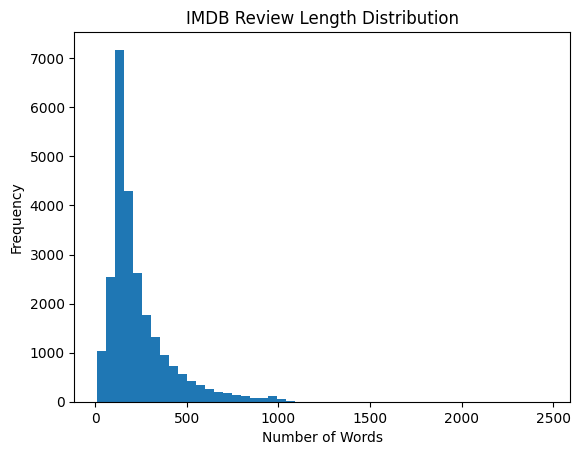

,review_length
count,25000.000000
mean,233.787200
std,173.733032
min,10.000000
25%,127.000000
50%,174.000000
75%,284.000000
max,2470.000000


In [ ]:
# Intial investigation of the IMDB dataset
print(imdb_train.columns)
print(imdb_train.shape)
print(imdb_train.head())

# Visualisation distribution
imdb_train["label"].value_counts().plot(kind="bar")
plt.title("IMDB Sentiment Distribution")
plt.xticks([0,1], ["Negative","Positive"], rotation=0)
plt.ylabel("Count")
plt.show()

# Review length
imdb_train["review_length"] = imdb_train["text"].apply(lambda x: len(x.split()))

plt.hist(imdb_train["review_length"], bins=50)
plt.title("IMDB Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()
imdb_train["review_length"].describe()

Step 3:
Cleaning the data for analysis.

In [ ]:
# Can see above that the TripAdvisor reviews are 1-5, we need this to be binary to compare with the IMDB reviews.
# Now we will change this to be ratings 1-2 = negative, 3 = removed and finally, 4-5 = positive.

trip_df = trip_df[trip_df["Rating"] != 3].copy()
trip_df["label"] = trip_df["Rating"].apply(lambda x: 1 if x >= 4 else 0)
trip_df = trip_df.rename(columns={"Review": "text"})
trip_df = trip_df[["text", "label"]]
print(trip_df["label"].value_counts())

label
1    15093
0     3214
Name: count, dtype: int64


In [ ]:
# Now we must ensure the data is seperated into train, test and validation sets.
# For IMDB:

imdb_train_df, imdb_val_df = train_test_split(
    imdb_train,
    test_size=0.1,
    stratify=imdb_train["label"],
    random_state=42
)

# And for TripAdvisor:
trip_train, trip_temp = train_test_split(
    trip_df,
    test_size=0.2,
    stratify=trip_df["label"],
    random_state=42
)

trip_val, trip_test = train_test_split(
    trip_temp,
    test_size=0.5,
    stratify=trip_temp["label"],
    random_state=42
)

# Check the splits:
print("IMDB train:", imdb_train_df.shape)
print("IMDB val:", imdb_val_df.shape)
print("IMDB test:", imdb_test.shape)

print("\nTripAdvisor train:", trip_train.shape)
print("TripAdvisor val:", trip_val.shape)
print("TripAdvisor test:", trip_test.shape)

print("\nTripAdvisor train labels:")
print(trip_train["label"].value_counts())

print("\nTripAdvisor val labels:")
print(trip_val["label"].value_counts())

print("\nTripAdvisor test labels:")
print(trip_test["label"].value_counts())

IMDB train: (22500, 3)
IMDB val: (2500, 3)
IMDB test: (25000, 2)

TripAdvisor train: (14645, 2)
TripAdvisor val: (1831, 2)
TripAdvisor test: (1831, 2)

TripAdvisor train labels:
label
1    12074
0     2571
Name: count, dtype: int64

TripAdvisor val labels:
label
1    1510
0     321
Name: count, dtype: int64

TripAdvisor test labels:
label
1    1509
0     322
Name: count, dtype: int64


The IMDB dataset provides predefined training and test sets. A validation set containing 10% of the training data was created using stratified sampling to maintain class balance.

Unlike the IMDB dataset, which is balanced between positive and negative reviews, the TripAdvisor dataset exhibits class imbalance, with a substantially higher proportion of positive reviews. This difference may influence classification performance and is considered when analysing model results.

In [ ]:
# Can also see that above, there are three collumns in the IMDB dataframe. This probably happened during the exploratory data stage. This needs resolved first:

imdb_train_df = imdb_train_df[["text","label"]]
imdb_val_df = imdb_val_df[["text","label"]]
imdb_test = imdb_test[["text","label"]]

In [ ]:
#Dataset Conversion for Transformer Models
imdb_ds = DatasetDict({
    "train": Dataset.from_pandas(imdb_train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(imdb_val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(imdb_test.reset_index(drop=True))
})

trip_ds = DatasetDict({
    "train": Dataset.from_pandas(trip_train.reset_index(drop=True)),
    "validation": Dataset.from_pandas(trip_val.reset_index(drop=True)),
    "test": Dataset.from_pandas(trip_test.reset_index(drop=True))
})

In [ ]:
# Add in metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
# Add in resuseable training function:

def run_experiment(model_name, dataset_dict, experiment_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            padding="max_length",
            max_length=256
        )

    tokenized_ds = dataset_dict.map(tokenize_function, batched=True)
    tokenized_ds = tokenized_ds.remove_columns(["text"])
    tokenized_ds.set_format("torch")

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=f"./{experiment_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=2,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        save_total_limit=1,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_ds["train"],
        eval_dataset=tokenized_ds["validation"],
        compute_metrics=compute_metrics
    )

    trainer.train()
    test_results = trainer.predict(tokenized_ds["test"])

    return trainer, test_results

In [ ]:
# Running one to test if it is working before running all four:

bert_imdb_trainer, bert_imdb_results = run_experiment(
    "bert-base-uncased",
    imdb_ds,
    "bert_imdb"
)

bert_imdb_results.metrics

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss
